In [125]:
import networkx as nx
import random
import matplotlib.pyplot as plt
import sys
import copy

In [126]:
max_capacity = 5

def shortest_path_length(a, b):
  return nx.astar_path(G, a, b),  nx.astar_path_length(G, a, b)

def generate_random_customers(G):
  nodes = list(G.nodes())
  node1 = random.choice(nodes)
  node2 = random.choice(nodes)

  while node1 == node2:
    node2 = random.choice(nodes)

  return node1, node2

def generate_random_activities(G, total_ticks=600, min_activities=450, max_activities=600):
    num_activities = (random.randint(min_activities, max_activities)) * 6
    ticks = random.choices(range(total_ticks), k=num_activities)
    activities = []
    nodes = list(G.nodes())

    for tick in ticks:
        source, destination = generate_random_customers(G)
        activities.append([tick, source, destination])

    return sorted(activities, key=lambda x: x[0])

def check_for_new_requests(tick, cx_requests):
  res = []
  temp_cx_requests = copy.deepcopy(cx_requests)
  for cx_request in temp_cx_requests:
    if cx_request[0] == tick:
      res.append(cx_request[1:])
      cx_requests.remove(cx_request)
  return res

def calculate_time(van, request_node, x, mode):
  total_weight = 0
  path = [van["current_pos"]]
  for i in range(x):
    path.extend(shortest_path_length(path[len(path) - 1], van["service_queue"][i][van["service_queue"][i][2]])[0][1:])
    if van["service_queue"][i][2] == 0:
      path.extend(shortest_path_length(path[len(path) - 1], van["service_queue"][i][1])[0][1:])
  for i in range(len(path) - 1):
    node_a = path[i]
    node_b = path[i + 1]
    if mode == 0 and node_a == request_node:
      return total_weight
    edge_weight = G[node_a][node_b]["weight"]
    total_weight += edge_weight
    if mode == 1 and node_b == request_node:
      return total_weight
  total_weight += shortest_path_length(path[len(path) - 1], request_node)[1]
  return total_weight

def assign_vans_to_customers(new_requests, vans, idle_vans, waiting_times):
    for new_request in new_requests:
        node1, node2 = new_request
        van_index = 0
        min_distance = sys.maxsize
        min_capacity = sys.maxsize
        flag = False

        for i in range(len(vans)):
            if vans[i]["current_capacity"] < max_capacity:
                path, van_length = shortest_path_length(vans[i]["current_pos"], node1)
                if van_length <= min_distance:
                    flag = True
                    if vans[i]["current_capacity"] >= min_capacity:
                        continue
                    min_capacity = vans[i]["current_capacity"]
                    van_index = i
                    min_distance = van_length

        if flag:
            vans[van_index]["service_queue"].append([node1, node2, 0])
            waiting_time = calculate_time(vans[van_index], node1, len(vans[van_index]["service_queue"]), 0)
            if(vans[van_index]["current_capacity"] == 0):
              idle_vans -= 1
            vans[van_index]["current_capacity"] += 1
            print(f"Customer [{node1}, {node2}] added to service queue of van {van_index + 1}, waiting time is {waiting_time}")
            waiting_times.append(waiting_time)
        else:
            print("All vans are currently busy, please try again in 15 minutes")
            break
    return idle_vans

def process_customer_pickups(vans, service_times):
  for van in vans:
    for i in range(len(van["service_queue"])):
      if van["current_pos"] == van["service_queue"][i][0] and van["service_queue"][i][2] != 1:
        service_time = calculate_time(van, van["service_queue"][i][1], i + 1, 1)
        print(f"Van {vans.index(van) + 1} picked up customer {van['service_queue'][i][:2]}, service time is {service_time}")
        van["service_queue"][i][2] = 1
        service_times.append(service_time)

def process_customer_dropoffs(vans, idle_vans):
    for van in vans:
      for i in range(len(van["service_queue"]) - 1, -1, -1):
        if van["service_queue"][i][1] == van["current_pos"] and van["service_queue"][i][2] == 1:
          drop = van["service_queue"].pop(i)
          print(f"Van {vans.index(van) + 1} dropped off customer {drop[:2]}")
          van["current_capacity"] -= 1
          van["trips"] += 1
          if van["current_capacity"] == 0:
            idle_vans += 1
    return idle_vans

def move_vans(vans, G):
  for van in vans:
    if van["service_queue"] != [] and van["path"] == []:
      if van["service_queue"][0][2] == 1:
        van["path"].extend(shortest_path_length(van["current_pos"], van["service_queue"][0][1])[0][1:])
      else:
        van["path"].extend(shortest_path_length(van["current_pos"], van["service_queue"][0][0])[0][1:])

    if van["path"] != []:
      van["traffic"] += 1
      if(van["traffic"] >= G[van["current_pos"]][van["path"][0]]["weight"]):
        van["traffic"] = 0
        van["current_pos"] = van["path"].pop(0)
        van["history"].append(van["current_pos"])
        print(f"Van {vans.index(van) + 1} moved to {van['current_pos']}")

def driver(G, number_of_vans, cx_requests):
  waiting_times = []
  service_times = []
  idle_vans = copy.deepcopy(number_of_vans)

  vans = []
  for i in range(number_of_vans):
    vans.append({"service_queue": [], "path": [], "current_capacity": 0, "traffic": 0, "current_pos": 1, "history" : [1], "trips": 0})

  tick = 1;
  while (tick <= 600 or idle_vans < number_of_vans):
    print(f"\n\033[1m##### TICK: {tick} #####\033[0m")
    move_vans(vans, G)
    new_requests =  check_for_new_requests(tick, cx_requests)
    idle_vans = assign_vans_to_customers(new_requests, vans, idle_vans, waiting_times)
    idle_vans = process_customer_dropoffs(vans, idle_vans)
    process_customer_pickups(vans, service_times)

    print()
    for i in range(len(vans)):
      print(f"Van {i + 1}:: Service Queue: {[e[:2] for e in vans[i]['service_queue']]}, Path Taken : {vans[i]['history']}")

    if cx_requests == [] and idle_vans == number_of_vans:
      break
    tick += 1
  return waiting_times, service_times, vans

def avg_waiting_service_trips(waiting_times, service_times, vans):
  print(f"Average Waiting Time: {sum(waiting_times) / len(waiting_times):.2f}")
  print(f"Average Service Time: {sum(service_times) / len(service_times):.2f}")
  print(f"Average Trips: {sum([van['trips'] for van in vans]) / len(vans):.2f}")

# R2

In [127]:
G=nx.Graph()
G.add_edges_from([(3, 9, {'weight': 2}),(1, 4, {'weight': 1}), (1, 9,{'weight': 1}), (4,9,{'weight': 1}), (9,2, {'weight': 1}), (9,7, {'weight': 1}), (2,7, {'weight': 1}),  (2,5, {'weight': 2}),  (7,5, {'weight': 1}),  (7,8,{'weight': 2}), (5,6, {'weight': 1}), (5,8, {'weight': 1}), (5,10, {'weight': 2}),(8,6, {'weight': 2}),(8,10, {'weight': 1})])

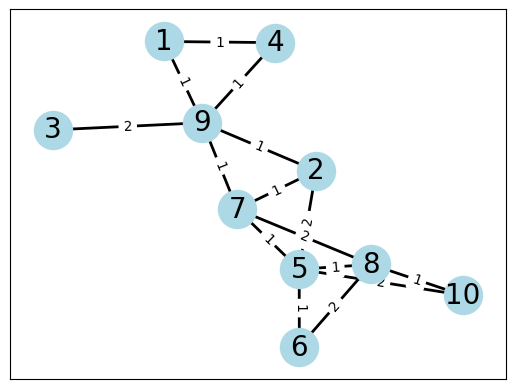

In [128]:
links = [(u, v) for (u, v, d) in G.edges(data=True)]
pos = nx.nx_pydot.graphviz_layout(G)
nx.draw_networkx_nodes(G, pos, node_size=800, node_color='lightblue', linewidths=0.05)
nx.draw_networkx_edges(G, pos, edgelist=links, width=2)

nx.draw_networkx_labels(G, pos, font_size=20, font_family="sans-serif")
edge_labels = nx.get_edge_attributes(G, 'weight','trips')
nx.draw_networkx_edge_labels(G, pos, edge_labels)

plt.show()

In [129]:
number_of_vans = 2
cx_requests = [[1, 1, 9], [1, 2, 6], [2, 5, 7], [2, 3, 4], [3, 4, 7], [3, 2, 10]]
waiting_times, service_times, vans = driver(G, number_of_vans, cx_requests)


##### TICK: 1 #####
Customer [1, 9] added to service queue of van 1, waiting time is 0
Customer [2, 6] added to service queue of van 2, waiting time is 2
Van 1 picked up customer [1, 9], service time is 1

Van 1:: Service Queue: [[1, 9]], Path Taken : [1]
Van 2:: Service Queue: [[2, 6]], Path Taken : [1]

##### TICK: 2 #####
Van 1 moved to 9
Van 2 moved to 9
Customer [5, 7] added to service queue of van 1, waiting time is 2
Customer [3, 4] added to service queue of van 2, waiting time is 9
Van 1 dropped off customer [1, 9]

Van 1:: Service Queue: [[5, 7]], Path Taken : [1, 9]
Van 2:: Service Queue: [[2, 6], [3, 4]], Path Taken : [1, 9]

##### TICK: 3 #####
Van 1 moved to 7
Van 2 moved to 2
Customer [4, 7] added to service queue of van 1, waiting time is 4
Customer [2, 10] added to service queue of van 1, waiting time is 7
Van 2 picked up customer [2, 6], service time is 3

Van 1:: Service Queue: [[5, 7], [4, 7], [2, 10]], Path Taken : [1, 9, 7]
Van 2:: Service Queue: [[2, 6], [3, 4]],

In [130]:
avg_waiting_service_trips(waiting_times, service_times, vans)

Average Waiting Time: 4.00
Average Service Time: 2.33
Average Trips: 3.00


# R3

In [131]:
p = 0.6
while(True):
  seed = random.randint(1, 100000)
  G= nx.gnp_random_graph (100, p, seed) # Random graph of connectivity 6
  if(nx.is_connected(G)):
    break
  p += 0.5
for u, v in G.edges():
    G[u][v]['weight'] = random.choice([1, 2])

cx_requests = generate_random_activities(G) # Generates the random requests 400 to 600 per hour
number_of_vans = 30
waiting_times, service_times, vans = driver(G, number_of_vans, cx_requests)

Output hidden; open in https://colab.research.google.com to view.

In [132]:
avg_waiting_service_trips(waiting_times, service_times, vans)

Average Waiting Time: 1.50
Average Service Time: 1.75
Average Trips: 111.70


# R4

In [133]:
cx_requests = generate_random_activities(G) # Generates the random requests 400 to 600 per hour
number_of_vans = 60
waiting_times, service_times, vans = driver(G, number_of_vans, cx_requests)

Streaming output truncated to the last 5000 lines.
Van 41:: Service Queue: [], Path Taken : [1]
Van 42:: Service Queue: [], Path Taken : [1]
Van 43:: Service Queue: [], Path Taken : [1]
Van 44:: Service Queue: [], Path Taken : [1]
Van 45:: Service Queue: [], Path Taken : [1]
Van 46:: Service Queue: [], Path Taken : [1]
Van 47:: Service Queue: [], Path Taken : [1]
Van 48:: Service Queue: [], Path Taken : [1]
Van 49:: Service Queue: [], Path Taken : [1]
Van 50:: Service Queue: [], Path Taken : [1]
Van 51:: Service Queue: [], Path Taken : [1]
Van 52:: Service Queue: [], Path Taken : [1]
Van 53:: Service Queue: [], Path Taken : [1]
Van 54:: Service Queue: [], Path Taken : [1]
Van 55:: Service Queue: [], Path Taken : [1]
Van 56:: Service Queue: [], Path Taken : [1]
Van 57:: Service Queue: [], Path Taken : [1]
Van 58:: Service Queue: [], Path Taken : [1]
Van 59:: Service Queue: [], Path Taken : [1]
Van 60:: Service Queue: [], Path Taken : [1]

##### TICK: 551 #####
Van 1 moved to 71
Van 3 mo

In [134]:
avg_waiting_service_trips(waiting_times, service_times, vans)

Average Waiting Time: 1.47
Average Service Time: 1.76
Average Trips: 54.55


# R5

In [136]:
p = 0.3
while(True):
  seed = random.randint(1, 100000)
  G= nx.gnp_random_graph (100, p, seed) # Random graph of connectivity 3
  if(nx.is_connected(G)):
    break
  p += 0.5
for u, v in G.edges():
    G[u][v]['weight'] = random.choice([1, 2])

cx_requests = generate_random_activities(G) # Generates the random requests 400 to 600 per hour
number_of_vans = 60
waiting_times, service_times, vans = driver(G, number_of_vans, cx_requests)

Streaming output truncated to the last 5000 lines.
Van 28:: Service Queue: [], Path Taken : [1, 33, 79, 49, 67, 16, 37, 60, 31, 39, 11, 64, 76, 70, 6, 66, 67, 36, 67, 35, 11, 83, 21, 49, 67, 36, 64, 62, 45, 50, 16, 39, 11, 43, 90, 46, 99, 55, 12, 82, 50, 48, 47, 21, 12, 24, 86, 21, 46]
Van 29:: Service Queue: [], Path Taken : [1, 30, 24, 86, 24, 8, 36, 22, 82, 38, 34, 48, 92, 51, 44, 49, 10, 46, 1, 46, 5, 82, 5, 21, 0, 55, 26, 39, 6, 87, 42, 6, 71, 7, 54, 70]
Van 30:: Service Queue: [], Path Taken : [1, 30, 39, 13, 45, 50, 21, 83, 3, 95, 84, 87, 43, 78, 4, 41, 70, 33, 92, 52, 65, 52, 25, 33, 79, 94, 0, 88, 57, 9, 26, 19, 89, 77, 30, 22, 40, 27, 69]
Van 31:: Service Queue: [[92, 99]], Path Taken : [1, 85, 61, 2, 69, 4, 48, 4, 32, 8, 39, 6, 85, 74, 63, 24, 79, 94, 71, 22, 36, 22, 82, 22, 79, 33, 18, 72, 22, 76, 61, 2, 7, 94, 68, 26, 32, 56, 5, 60, 52, 92, 48]
Van 32:: Service Queue: [], Path Taken : [1, 30, 32, 8, 39, 96, 34, 89, 34, 18, 72, 4, 48, 83, 6, 87, 66, 67, 95, 5, 16, 31, 49, 9

In [137]:
avg_waiting_service_trips(waiting_times, service_times, vans)

Average Waiting Time: 1.73
Average Service Time: 1.97
Average Trips: 45.88
